## Introduction  
This project focuses on analyzing hotel booking data using Python to uncover key trends and patterns. The analysis explores various aspects of the dataset, such as booking behaviors, cancellation rates, and pricing trends, with the goal of providing actionable insights for optimizing hotel operations.  

- **Objective**:  
  - Investigate booking trends, including cancellation rates, lead times, and seasonal variations, for City Hotel and Resort Hotel.  
  - Offer data-driven insights to improve revenue management and operational efficiency.  

- **Dataset**:  
  - Contains 119,390 records with 36 features, including details on booking status, customer demographics, pricing, and special requests.  
  - Data cleaning steps included handling missing values, dropping irrelevant columns, and addressing outliers.  

- **Libraries Used**:  
  - `pandas` and `numpy`: For data processing and analysis.  
  - `matplotlib` and `seaborn`: For creating insightful visualizations such as bar charts, line plots, and imize operational decisions.  


# Importing Libraries

In [ ]:
# to store and process data in dataframes
import pandas as pd
# basic visualization package
import matplotlib.pyplot as plt
# advanced ploting
import seaborn as sns
# hide warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# color pallette
edge, prim, sec, ter = '#393e46', '#3269a8', '#32a0a8', '#32a86f'

# seaborn plot style
sns.set_style('darkgrid')

# Loading the Dataset

In [ ]:
# Upload file from your local machine in Google Colab
from google.colab import files
import io

uploaded = files.upload()  # This will prompt you to upload a CSV file
file_name = list(uploaded.keys())[0]
full_table = pd.read_csv(io.BytesIO(uploaded[file_name]))


Saving hotel_bookings.csv to hotel_bookings.csv


# Data Understanding & Cleaning

In [ ]:
full_table.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
full_table.shape

(119390, 32)

In [ ]:
full_table.info(verbose=True, show_counts=True)

# For a more detailed summary of your DataFrame, including data types and counts:
#full_table.describe(include='all').transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
full_table['reservation_status_date'] = pd.to_datetime(full_table['reservation_status_date'])

In [ ]:
# Object datatypes columns usually house categorical data. To get details on the same
full_table.describe(include = 'object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166


In [ ]:
for col in full_table.describe(include = 'object').columns:
    print(col)
    print(full_table[col].unique())
    print('-'*50)

hotel
['Resort Hotel' 'City Hotel']
--------------------------------------------------
arrival_date_month
['July' 'August' 'September' 'October' 'November' 'December' 'January'
 'February' 'March' 'April' 'May' 'June']
--------------------------------------------------
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
--------------------------------------------------
country
['PRT' 'GBR' 'USA' 'ESP' 'IRL' 'FRA' nan 'ROU' 'NOR' 'OMN' 'ARG' 'POL'
 'DEU' 'BEL' 'CHE' 'CN' 'GRC' 'ITA' 'NLD' 'DNK' 'RUS' 'SWE' 'AUS' 'EST'
 'CZE' 'BRA' 'FIN' 'MOZ' 'BWA' 'LUX' 'SVN' 'ALB' 'IND' 'CHN' 'MEX' 'MAR'
 'UKR' 'SMR' 'LVA' 'PRI' 'SRB' 'CHL' 'AUT' 'BLR' 'LTU' 'TUR' 'ZAF' 'AGO'
 'ISR' 'CYM' 'ZMB' 'CPV' 'ZWE' 'DZA' 'KOR' 'CRI' 'HUN' 'ARE' 'TUN' 'JAM'
 'HRV' 'HKG' 'IRN' 'GEO' 'AND' 'GIB' 'URY' 'JEY' 'CAF' 'CYP' 'COL' 'GGY'
 'KWT' 'NGA' 'MDV' 'VEN' 'SVK' 'FJI' 'KAZ' 'PAK' 'IDN' 'LBN' 'PHL' 'SEN'
 'SYC' 'AZE' 'BHR' 'NZL' 'THA' 'DOM' 'MKD' 'MYS' 'ARM' 'JPN' 'LKA' 'CUB'
 'CMR' 'BIH' 'MUS' 'COM' 'SUR' 'UGA' 'BGR' 'CIV' 'J

In [ ]:
full_table.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
''' Country has huge amount of records missing and is not relevant to the currently analysis, the same could be said for agent,
hence both these columns are dropped.
children has 4 and country has 488 null records which considered in relation to the dataset of about 1.5 lakhs is insignificant,
hence these rows can be dropped
'''
full_table.drop(['company', 'agent'], axis = 1, inplace = True)
full_table.dropna(inplace = True)
full_table.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type',
       'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [ ]:
full_table.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2016.157656,27.166555,15.800880,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2016-07-30 07:37:53.336809984
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483168,106.903309,0.707459,13.589971,8.780324,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


In [ ]:
# Of all the outliers only the Average Daily Rate is relevant to our analysis hence we handle the outlier in that column
full_table = full_table[full_table['adr']<5000]
full_table.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897.000000,118897
mean,0.371347,104.312018,2016.157657,27.166674,15.800802,0.928905,2.502157,1.858390,0.104208,0.007948,0.032011,0.087143,0.131635,0.221175,2.330774,101.958683,0.061885,0.571688,2016-07-30 07:39:51.289939968
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2016-02-02 00:00:00
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2016-08-08 00:00:00
75%,1.000000,161.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2017-02-09 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,510.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.483167,106.903570,0.707462,13.589966,8.780321,0.996217,1.900171,0.578578,0.399174,0.097381,0.176030,0.845872,1.484678,0.652784,17.630525,48.091199,0.244173,0.792680,NaN


# Data Analysis & Visualizations

is_canceled
0    0.628653
1    0.371347
Name: proportion, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

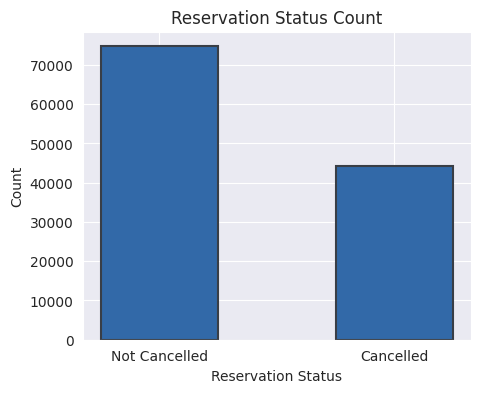

In [ ]:
# Getting percentage of cancelled and non co
cancelled_percentage = full_table['is_canceled'].value_counts(normalize = True)
print(cancelled_percentage) # Based on our dataset 0 = False and 1 = True

# Setup plot
plt.figure(figsize = (5,4))
plt.bar(['Not Cancelled', 'Cancelled'], full_table['is_canceled'].value_counts(), color = prim, edgecolor = edge, linewidth = 1.5, width = 0.5)

# Enhance the plot
plt.xlabel('Reservation Status')
plt.ylabel('Count')
plt.title('Reservation Status Count')

# Display the plot
plt.show

In [ ]:
# Analyse and compare the cancellation for each hotel
full_grouped = full_table.groupby(['hotel'])['is_canceled']
full_grouped.value_counts(normalize = True)

hotel         is_canceled
City Hotel    0              0.582918
              1              0.417082
Resort Hotel  0              0.720250
              1              0.279750
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

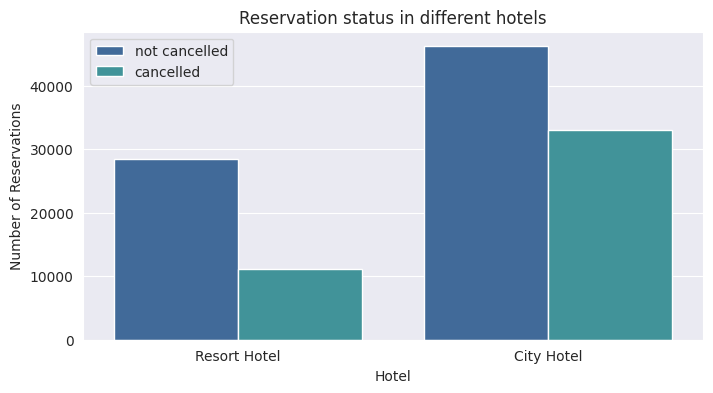

In [ ]:
# Analyse and compare the cancellation for each hotel
# Setup plot
plt.figure(figsize = (8,4))
ax1 = sns.countplot(x = 'hotel', hue = 'is_canceled', data = full_table, palette = [prim, sec])

# Enhance the plot
plt.legend(loc = 'upper left', labels=['not cancelled', 'cancelled'])
plt.title('Reservation status in different hotels')
plt.xlabel('Hotel')
plt.ylabel('Number of Reservations')

# Display the plot
plt.show

In [ ]:
# Analyse impact of price on cancellation rates
resort_hotel = full_table[full_table['hotel'] == 'Resort Hotel'].groupby('reservation_status_date')[['adr']].mean()
resort_hotel

,adr
reservation_status_date,
2014-11-18,0.000000
2015-01-01,61.966667
2015-01-02,9.633750
2015-01-18,0.000000
2015-01-21,37.301209
...,...
2017-09-08,101.012500
2017-09-09,147.778333
2017-09-10,145.272500


In [ ]:
city_hotel = full_table[full_table['hotel'] == 'City Hotel'].groupby('reservation_status_date')[['adr']].mean()
city_hotel

,adr
reservation_status_date,
2014-10-17,62.800000
2015-01-01,62.063158
2015-01-20,76.500000
2015-01-30,61.400000
2015-02-17,76.500000
...,...
2017-09-03,137.172600
2017-09-04,116.925385
2017-09-05,154.000000


<function matplotlib.pyplot.show(close=None, block=None)>

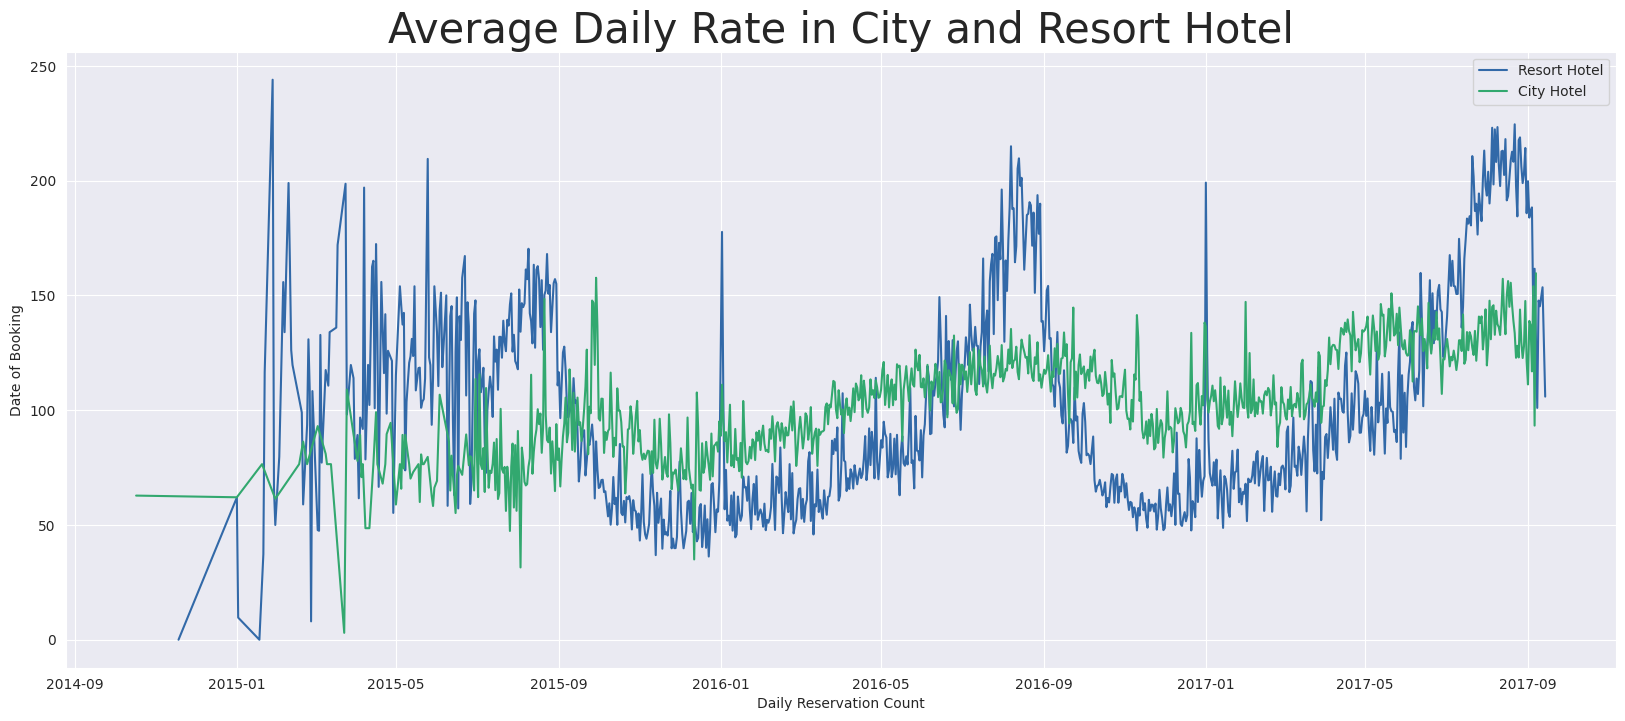

In [ ]:
# Visualize prices of average daily rates for both hotels
# Set up the plot
plt.figure(figsize = (20,8))
plt.plot(resort_hotel.index, resort_hotel['adr'], label = 'Resort Hotel', color=prim)
plt.plot(city_hotel.index, city_hotel['adr'], label = 'City Hotel', color=ter)

# Enhance the plot
plt.xlabel('Daily Reservation Count')
plt.ylabel('Date of Booking')
plt.title('Average Daily Rate in City and Resort Hotel', fontsize = 30)
plt.legend(loc = 'best', labels=['Resort Hotel', 'City Hotel'])

# Display the plot
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

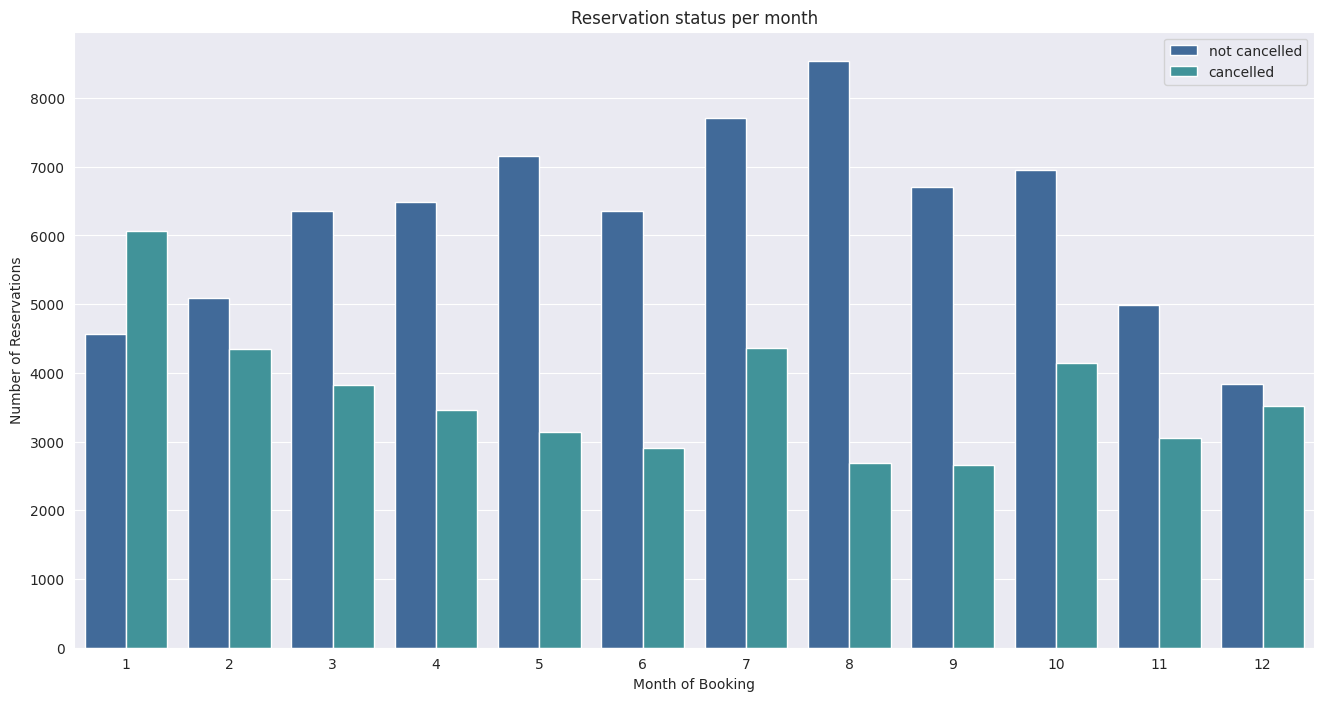

In [ ]:
full_table['reservation_status_month'] = full_table['reservation_status_date'].dt.month

# Set up the plot
plt.figure(figsize = (16, 8))
ax1 = sns.countplot(x = 'reservation_status_month', hue = 'is_canceled', data = full_table, palette = [prim, sec])

# Enhance the plot
plt.legend(loc = 'best', labels=['not cancelled', 'cancelled'])
plt.title('Reservation status per month')
plt.xlabel('Month of Booking')
plt.ylabel('Number of Reservations')

# Display the plot
plt.show

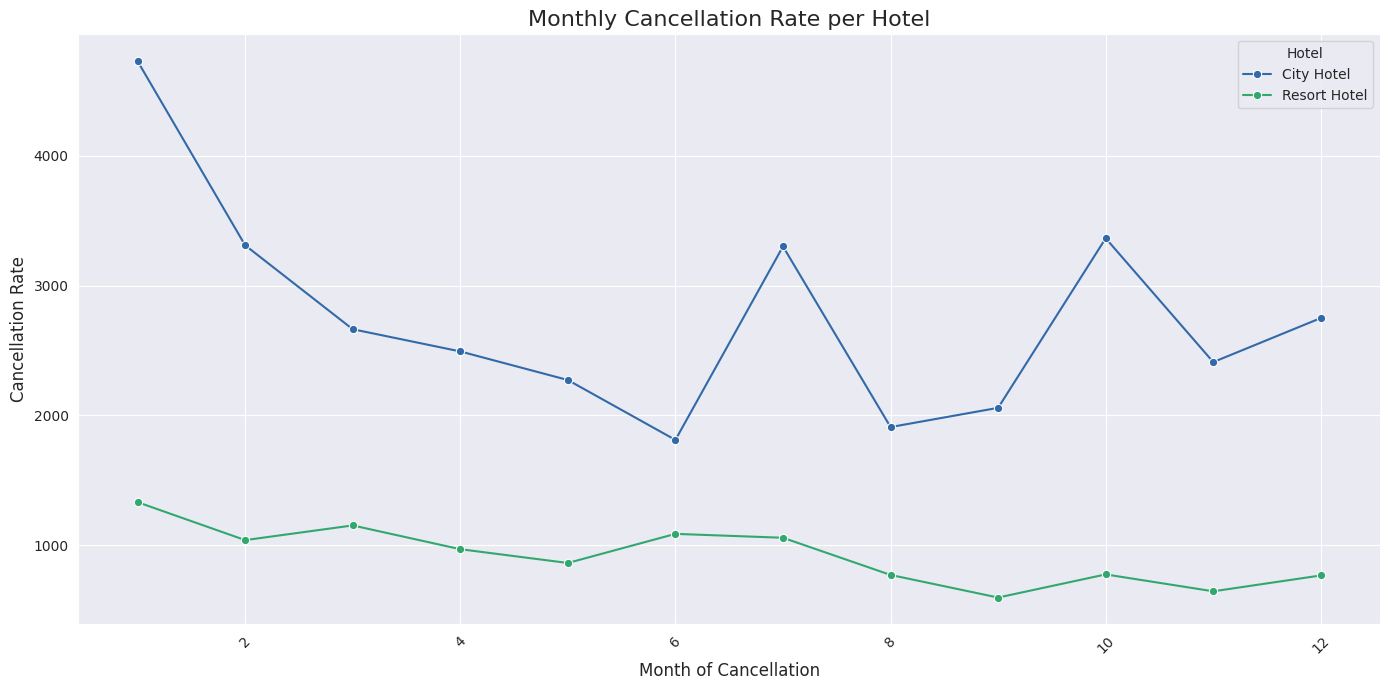

In [ ]:
monthly_cancellations = full_table.groupby(['hotel', 'reservation_status_month'])['is_canceled'].sum().reset_index()

# Set up the plot
plt.figure(figsize=(14, 7))
sns.lineplot(x='reservation_status_month', y='is_canceled', hue='hotel', data=monthly_cancellations, marker='o', palette = [prim, ter])

# Enhance the plot
plt.title('Monthly Cancellation Rate per Hotel', fontsize=16)
plt.xlabel('Month of Cancellation', fontsize=12)
plt.ylabel('Cancellation Rate', fontsize=12)
plt.xticks(rotation=45)  # Rotate x-axis labels to make them readable
plt.legend(title='Hotel')

# Display the plot
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

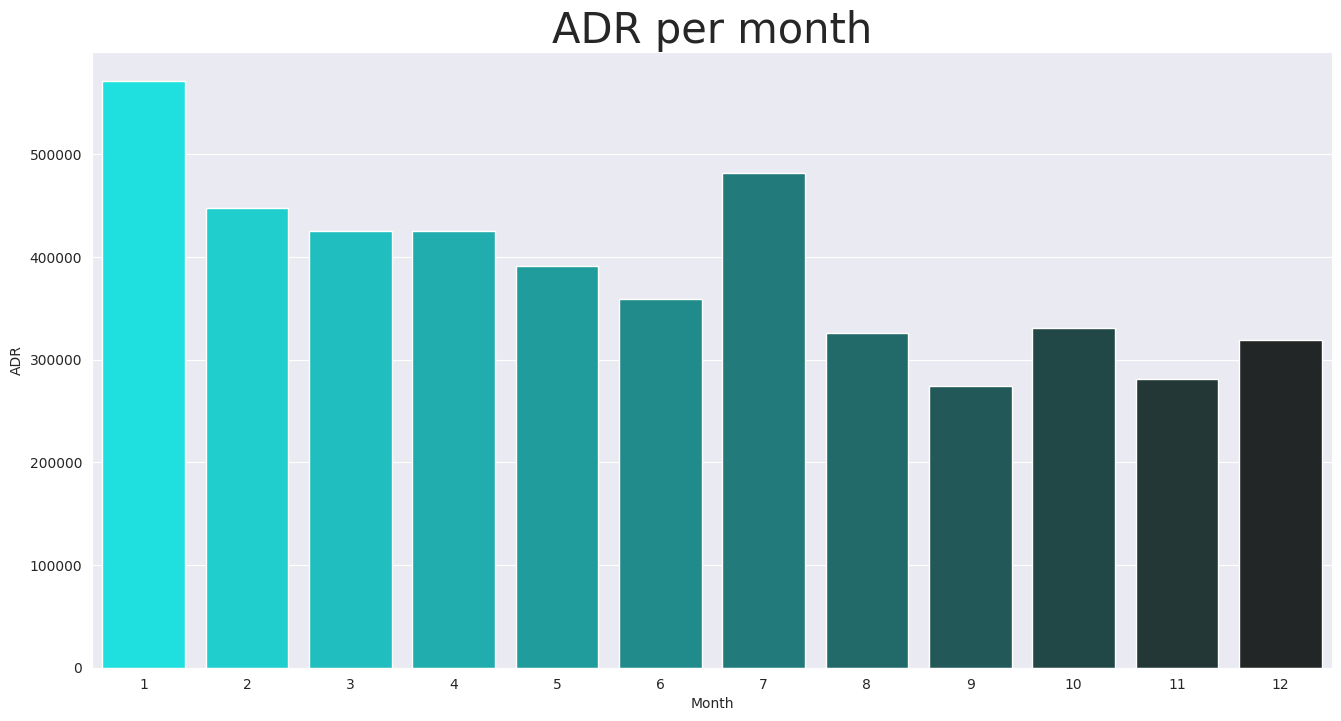

In [ ]:
monthly_adr = full_table[full_table['is_canceled'] == 1].groupby('reservation_status_month')[['adr']].sum().reset_index()
dark_blue_palette = sns.dark_palette("cyan", reverse=True, n_colors=len(monthly_adr))
# Setup plot
plt.figure(figsize = (16, 8))
sns.barplot(x='reservation_status_month', y='adr', data = monthly_adr, palette = dark_blue_palette)

# Enhance the plot
plt.xlabel('Month')
plt.ylabel('ADR')
plt.title('ADR per month', fontsize = 30)

# Display the plot
plt.show

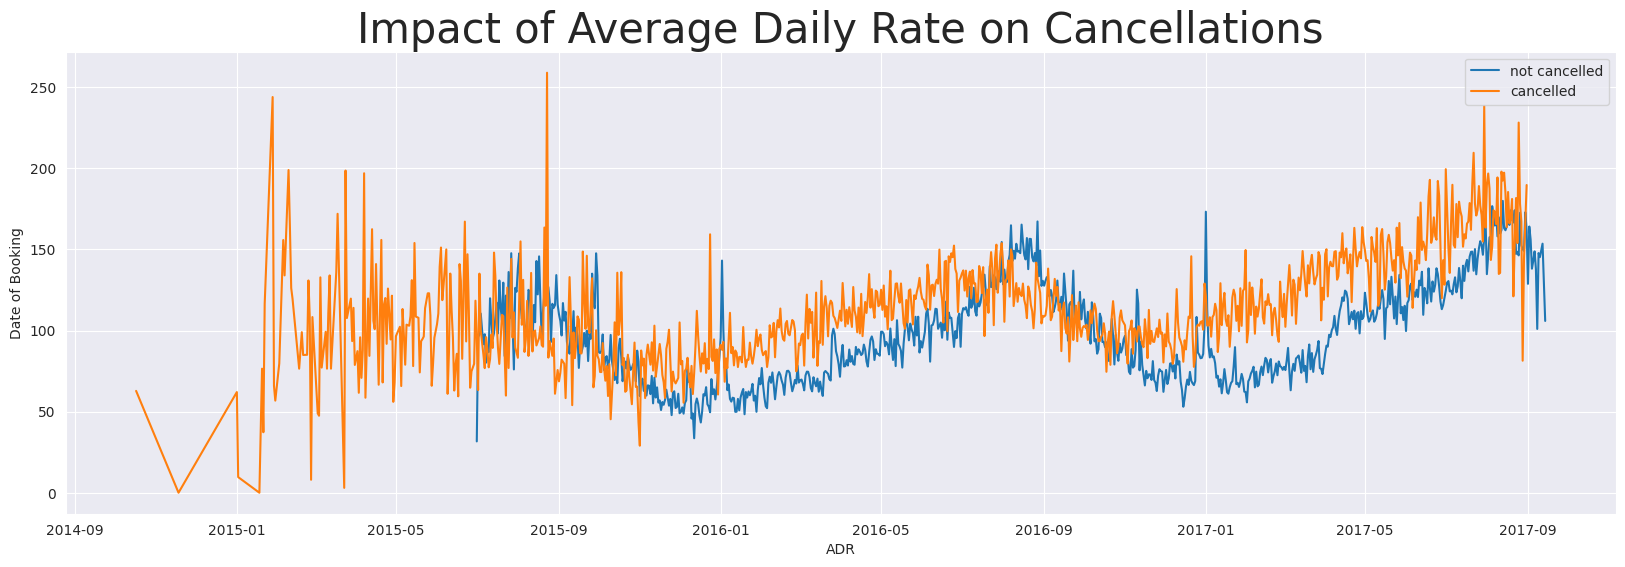

In [ ]:
# Analyzing the relation between mean adr and cancellation over months for all available data

cancelled_data = full_table[(full_table['is_canceled'] == 1)]
not_cancelled_data = full_table[(full_table['is_canceled'] == 0)]

cancelled_df_adr = cancelled_data.groupby('reservation_status_date')[['adr']].mean()
cancelled_df_adr.reset_index(inplace=True)
cancelled_df_adr.sort_values('reservation_status_date', ascending = True, inplace = True)

not_cancelled_df_adr = not_cancelled_data.groupby('reservation_status_date')[['adr']].mean()
not_cancelled_df_adr.reset_index(inplace=True)
not_cancelled_df_adr.sort_values('reservation_status_date', ascending = True, inplace = True)

# Visualizing the relation between mean adr and cancellation over months
#Setup plot
plt.figure(figsize = (20, 6))
plt.plot(not_cancelled_df_adr['reservation_status_date'], not_cancelled_df_adr['adr'], label = 'not cancelled')
plt.plot(cancelled_df_adr['reservation_status_date'], cancelled_df_adr['adr'], label = 'cancelled')

# Enhance the plot
plt.xlabel('ADR')
plt.ylabel('Date of Booking')
plt.title('Impact of Average Daily Rate on Cancellations', fontsize = 30)
plt.legend()

#Show the plot
plt.show()

In [ ]:
cancelled_df_adr.columns

Index(['reservation_status_date', 'adr'], dtype='object')

Cancelled data length: 607
Not Cancelled data length: 608


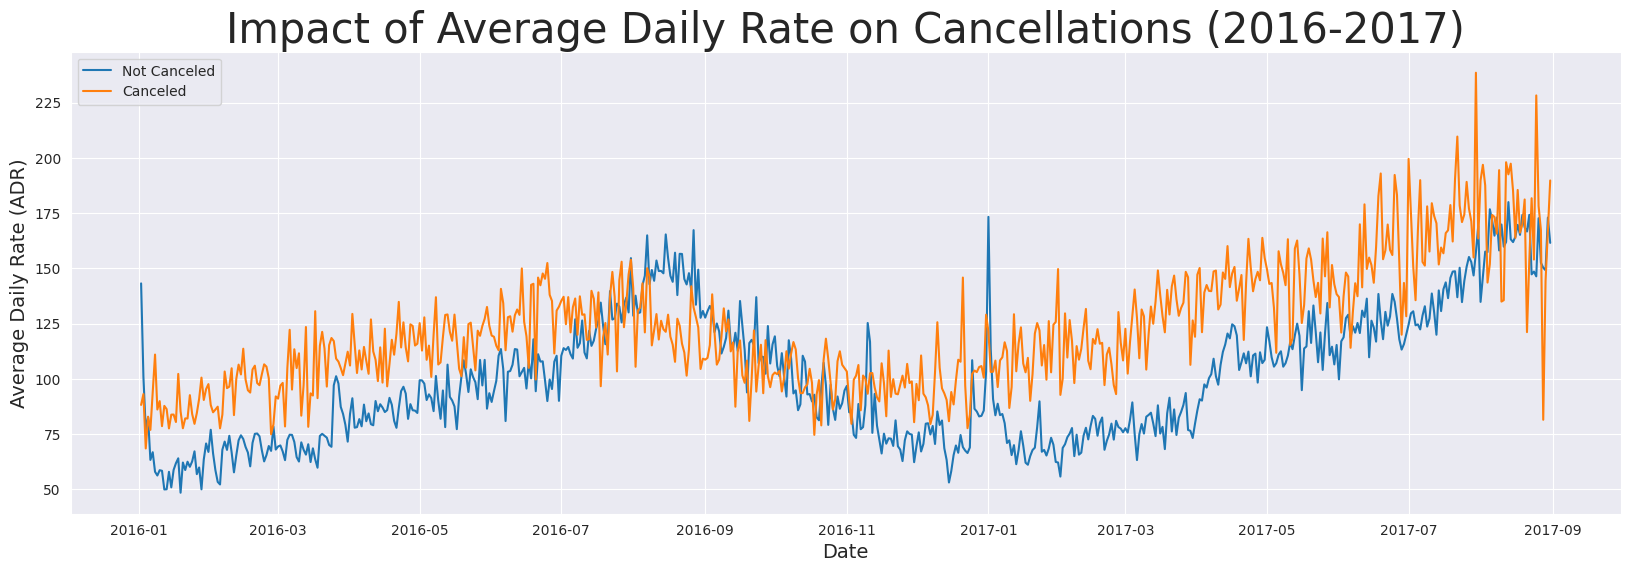

In [ ]:
# Analyzing the relation between mean adr and cancellation over months between 2016 to 2017

# Ensure 'reservation_status_date' is in datetime format (this is just a safety check)
cancelled_df_adr['reservation_status_date'] = pd.to_datetime(cancelled_df_adr['reservation_status_date'])
not_cancelled_df_adr['reservation_status_date'] = pd.to_datetime(not_cancelled_df_adr['reservation_status_date'])

# Filter data based on the date range
start_date = '2016-01-01'
end_date = '2017-09-01'

cancelled_df_adr = cancelled_df_adr[(cancelled_df_adr['reservation_status_date'] > start_date) &
                                      (cancelled_df_adr['reservation_status_date'] < end_date)]

not_cancelled_df_adr = not_cancelled_df_adr[(not_cancelled_df_adr['reservation_status_date'] > start_date) &
                                            (not_cancelled_df_adr['reservation_status_date'] < end_date)]

# Check lengths after filtering
print(f"Cancelled data length: {len(cancelled_df_adr)}")
print(f"Not Cancelled data length: {len(not_cancelled_df_adr)}")

# Ensure data is sorted by 'reservation_status_date'
cancelled_df_adr.sort_values('reservation_status_date', inplace=True)
not_cancelled_df_adr.sort_values('reservation_status_date', inplace=True)

# Setup plot
plt.figure(figsize=(20, 6))

# Plot the data
plt.plot(not_cancelled_df_adr['reservation_status_date'], not_cancelled_df_adr['adr'], label='Not Canceled')
plt.plot(cancelled_df_adr['reservation_status_date'], cancelled_df_adr['adr'], label='Canceled')

# Enhance the plot
plt.title('Impact of Average Daily Rate on Cancellations (2016-2017)', fontsize=30)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Average Daily Rate (ADR)', fontsize=14)
plt.legend()

# Show the plot
plt.show()


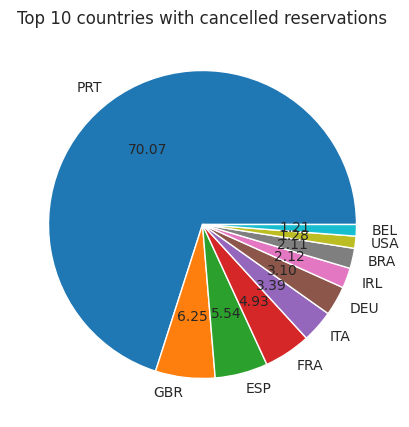

In [ ]:
# Identifying the top countries with respect to cancellations
top_10_country = cancelled_data['country'].value_counts()[:10]

# Setup plot
plt.figure(figsize = (5,5))
plt.pie(top_10_country, autopct = '%.2f', labels = top_10_country.index)

# Enhance the plot
plt.title('Top 10 countries with cancelled reservations')

# Show the plot
plt.show()

In [ ]:
full_table['market_segment'].value_counts()

,count
market_segment,
Online TA,56402
Offline TA/TO,24159
Groups,19806
Direct,12448
Corporate,5111
Complementary,734
Aviation,237


## Conclusion  
The analysis of the hotel booking dataset reveals several important trends and provides actionable insights:  

- **Key Findings**:  
  - **Cancellation Rates**:  
    - City Hotel has a higher cancellation rate (41.7%) compared to Resort Hotel (27.9%).  
    - Cancellations are more frequent with longer lead times.  
  - **Pricing Insights**:  
    - Average Daily Rates (ADR) exhibit seasonal variations, peaking during summer months.  
    - Resort Hotel typically maintains a higher ADR than City Hotel.  
  - **Seasonal Patterns**:  
    - Monthly booking patterns show significant fluctuations, with higher cancellations during peak seasons.  

- **Future Enhancements**:  
  - Perform customer segmentation to understand different booking behaviors.  
  - Use predictive modeling to forecast cancellations and optimize operational decisions.  

Classification Model – Predicting Booking Cancellations

In [ ]:
# Import libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Encode categorical variables
encoded_df = full_table.copy()
for col in encoded_df.select_dtypes(include='object').columns:
    if col != 'reservation_status_date':
        encoded_df[col] = LabelEncoder().fit_transform(encoded_df[col].astype(str))

# Define features and target
features = ['lead_time', 'hotel', 'arrival_date_month', 'customer_type',
            'market_segment', 'deposit_type', 'previous_cancellations',
            'total_of_special_requests']
X = encoded_df[features]
y = encoded_df['is_canceled']

# Train-test split and CV setup
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



Random Forest

Random Forest - Mean ROC AUC: 0.8719610908491007


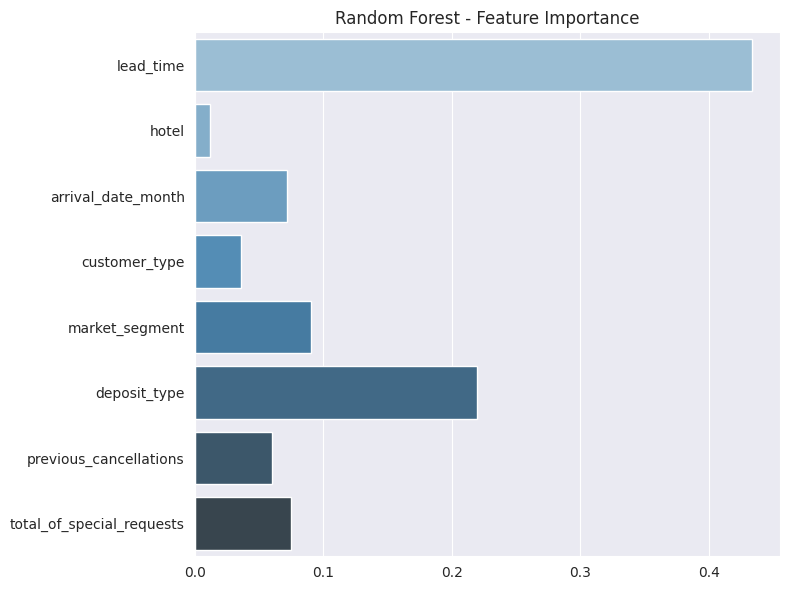

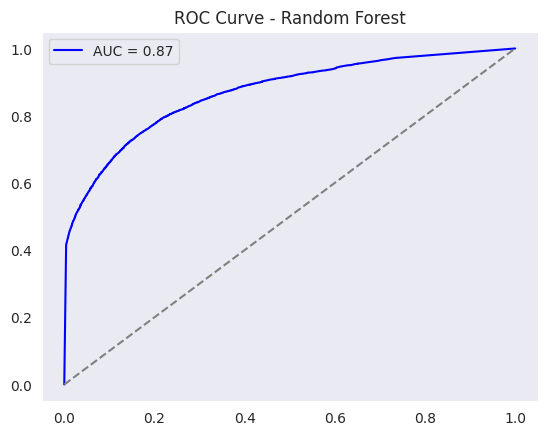

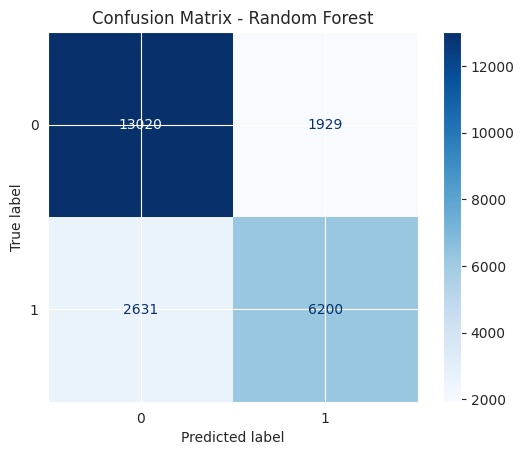

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf_model, X, y, cv=cv, scoring='roc_auc')
print("Random Forest - Mean ROC AUC:", rf_scores.mean())

rf_model.fit(X_train, y_train)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)

# Feature Importance
plt.figure(figsize=(8, 6))
sns.barplot(x=rf_model.feature_importances_, y=features, palette='Blues_d')
plt.title("Random Forest - Feature Importance")
plt.tight_layout()
plt.show()

# ROC Curve & Confusion Matrix
fpr, tpr, _ = roc_curve(y_test, rf_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='blue')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve - Random Forest")
plt.legend(); plt.grid(); plt.show()

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()


Logistic Regression

Logistic Regression - Mean ROC AUC: 0.8038269594416365


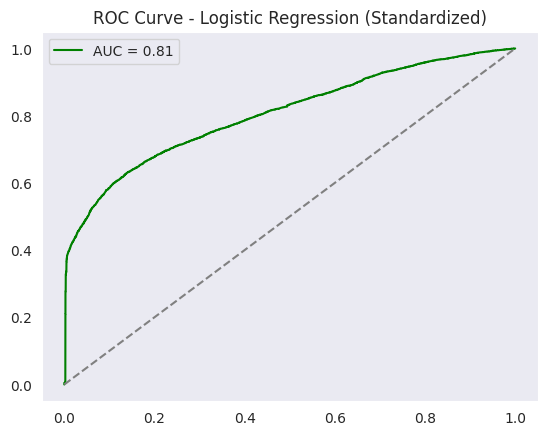

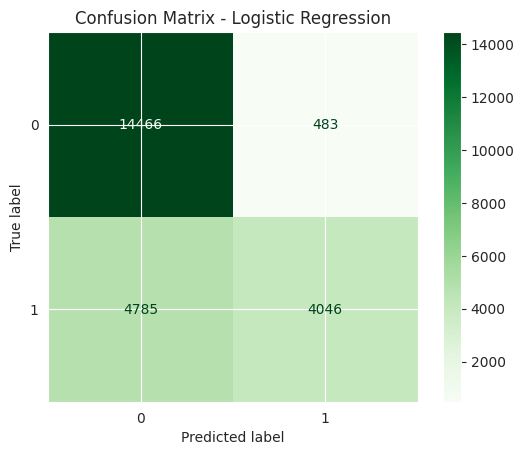

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Create pipeline: StandardScaler + LogisticRegression
log_pipeline = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))

# Cross-validation with standardized data
log_scores = cross_val_score(log_pipeline, X, y, cv=cv, scoring='roc_auc')
print("Logistic Regression - Mean ROC AUC:", log_scores.mean())

# Fit pipeline on training data
log_pipeline.fit(X_train, y_train)

# Predict probabilities and labels
log_proba = log_pipeline.predict_proba(X_test)[:, 1]
log_pred = log_pipeline.predict(X_test)

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, log_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='green')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve - Logistic Regression (Standardized)")
plt.legend(); plt.grid(); plt.show()

# --- Confusion Matrix ---
ConfusionMatrixDisplay.from_estimator(log_pipeline, X_test, y_test, cmap='Greens')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Decision Tree

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}


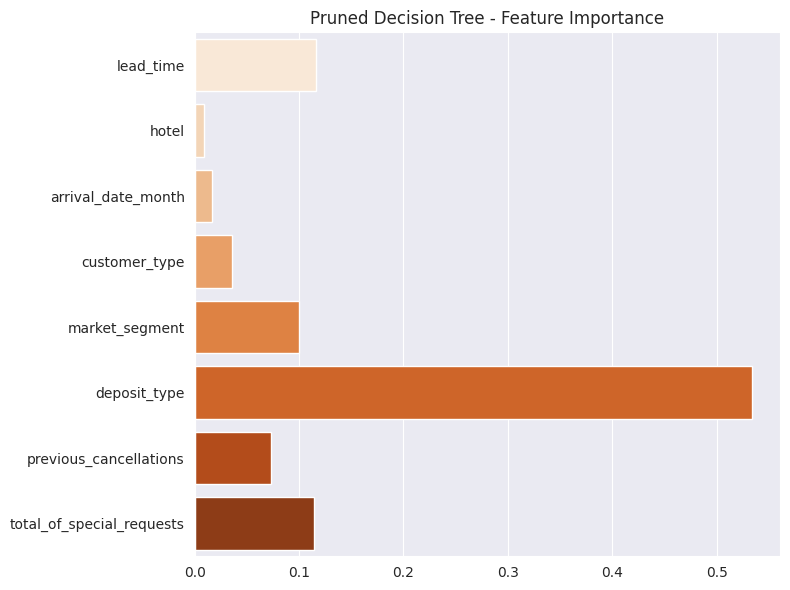

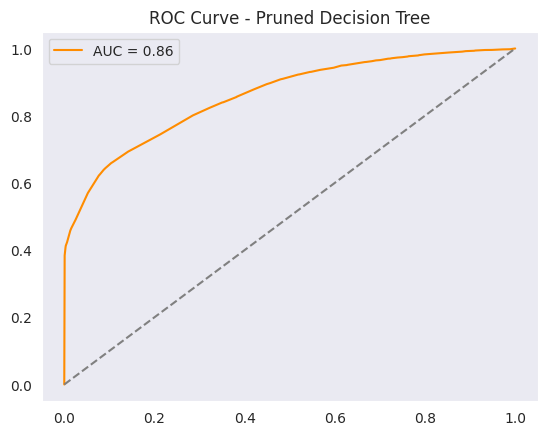

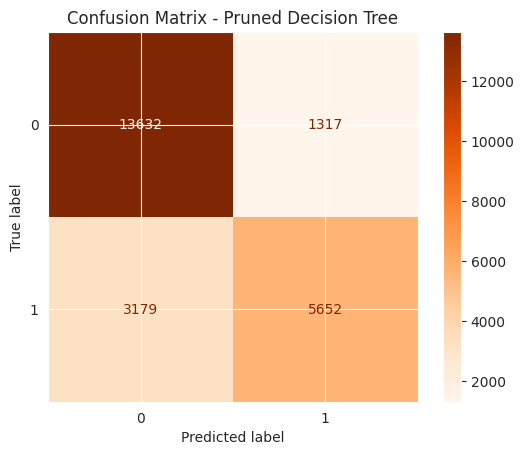

Classification Report - Pruned Decision Tree
              precision    recall  f1-score   support

           0       0.81      0.91      0.86     14949
           1       0.81      0.64      0.72      8831

    accuracy                           0.81     23780
   macro avg       0.81      0.78      0.79     23780
weighted avg       0.81      0.81      0.81     23780



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay, classification_report

# --- Define parameter grid ---
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# --- GridSearchCV setup ---
dt = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

# --- Best pruned Decision Tree ---
best_dt = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# --- Evaluate on test set ---
dt_proba = best_dt.predict_proba(X_test)[:, 1]
dt_pred = best_dt.predict(X_test)

# --- Feature Importance ---
plt.figure(figsize=(8, 6))
sns.barplot(x=best_dt.feature_importances_, y=features, palette='Oranges')
plt.title("Pruned Decision Tree - Feature Importance")
plt.tight_layout()
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, dt_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}', color='darkorange')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve - Pruned Decision Tree")
plt.legend(); plt.grid(); plt.show()

# --- Confusion Matrix ---
ConfusionMatrixDisplay.from_estimator(best_dt, X_test, y_test, cmap='Oranges')
plt.title("Confusion Matrix - Pruned Decision Tree")
plt.show()

# --- Classification Report ---
print("Classification Report - Pruned Decision Tree")
print(classification_report(y_test, dt_pred))


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

# Collect predictions for each model
# Replace these with actual values from your models
models = {
    "Random Forest": (rf_pred, rf_proba),
    "Logistic Regression": (log_pred, log_proba),
    "Decision Tree": (dt_pred, dt_proba)
}

# Initialize results list
results = []

# Evaluate each model
for name, (y_pred, y_proba) in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC AUC": roc
    })

# Create and display comparison DataFrame
comparison_df = pd.DataFrame(results)
print(comparison_df)


                 Model  Accuracy  Precision    Recall  F1-Score   ROC AUC
0        Random Forest  0.808242   0.762701  0.702072  0.731132  0.868962
1  Logistic Regression  0.778469   0.893354  0.458159  0.605689  0.805561
2        Decision Tree  0.810934   0.811020  0.640018  0.715443  0.859643


 Regression Model – Predicting Average Daily Rate (ADR)

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Define regression features
additional_features = ['hotel', 'arrival_date_month', 'stays_in_weekend_nights',
                       'stays_in_week_nights', 'meal', 'market_segment',
                       'reservation_status_month', 'reserved_room_type',
                       'assigned_room_type', 'country', 'adults', 'children',
                       'babies', 'total_of_special_requests']

# Choose hotel type: 1 = Resort, 0 = City
hotel_type = 1

# Filter and encode
subset = encoded_df[encoded_df['hotel'] == hotel_type]
X_hotel = subset[additional_features].copy()
y_hotel = subset['adr']

# Encode any object-type columns
for col in X_hotel.select_dtypes(include='object'):
    X_hotel[col] = LabelEncoder().fit_transform(X_hotel[col].astype(str))



Linear Regression

Linear Regression (Standardized):
Mean R2: 0.35463150547210304
Mean RMSE: 49.39654946040785


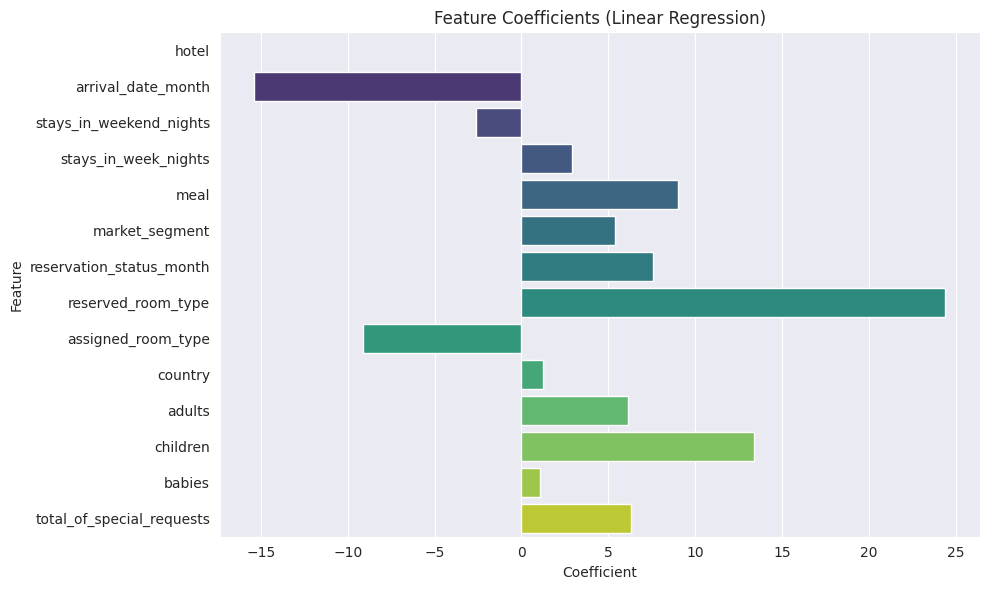

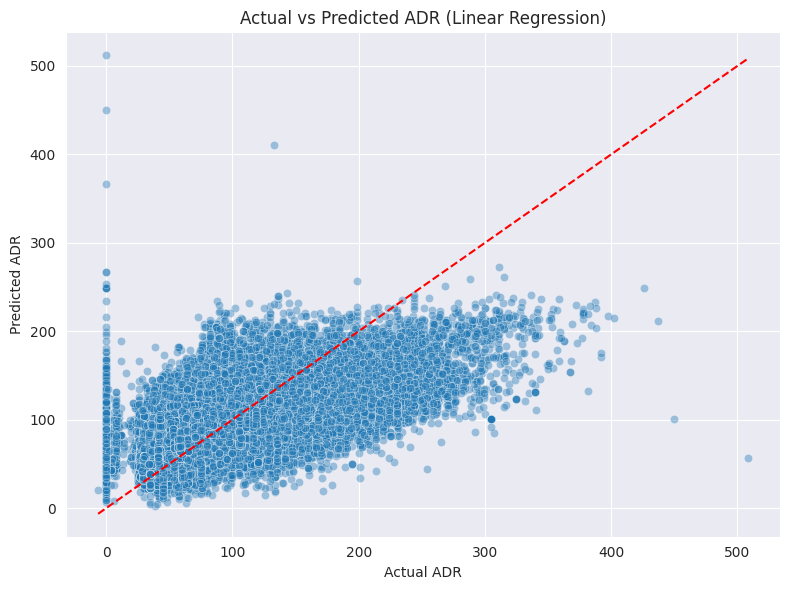

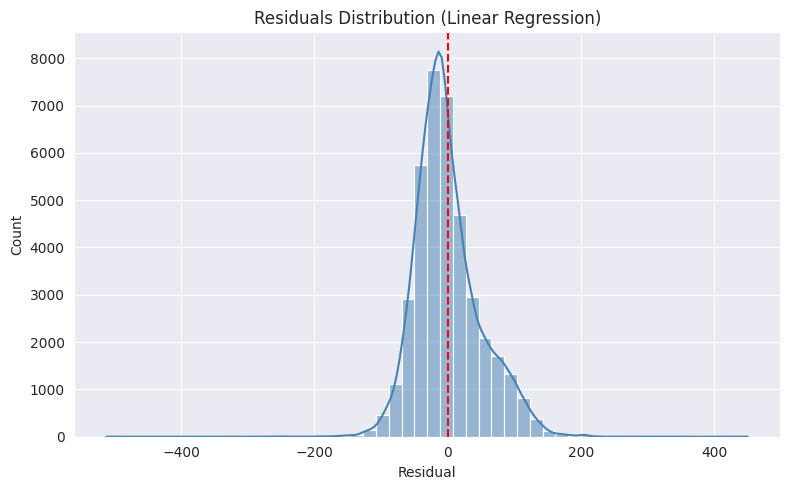

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr_pipeline = make_pipeline(StandardScaler(), LinearRegression())

r2_scores_lr, rmse_scores_lr = [], []

# K-Fold CV
for train_idx, test_idx in kf.split(X_hotel):
    X_train, X_test = X_hotel.iloc[train_idx], X_hotel.iloc[test_idx]
    y_train, y_test = y_hotel.iloc[train_idx], y_hotel.iloc[test_idx]

    lr_pipeline.fit(X_train, y_train)
    y_pred = lr_pipeline.predict(X_test)

    r2_scores_lr.append(r2_score(y_test, y_pred))
    rmse_scores_lr.append(np.sqrt(mean_squared_error(y_test, y_pred)))

print("Linear Regression (Standardized):")
print("Mean R2:", np.mean(r2_scores_lr))
print("Mean RMSE:", np.mean(rmse_scores_lr))

# ===== Visualization =====

# Fit once on full data for visualization
lr_pipeline.fit(X_hotel, y_hotel)
y_pred_all = lr_pipeline.predict(X_hotel)

# 1. Feature Importance (coefficients)
coefficients = lr_pipeline.named_steps['linearregression'].coef_
plt.figure(figsize=(10, 6))
sns.barplot(x=coefficients, y=X_hotel.columns, palette='viridis')
plt.title("Feature Coefficients (Linear Regression)")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 2. Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_hotel, y=y_pred_all, alpha=0.4)
plt.plot([y_hotel.min(), y_hotel.max()], [y_hotel.min(), y_hotel.max()], '--', color='red')
plt.title("Actual vs Predicted ADR (Linear Regression)")
plt.xlabel("Actual ADR")
plt.ylabel("Predicted ADR")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Residuals
residuals = y_hotel - y_pred_all
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=50, color='steelblue')
plt.title("Residuals Distribution (Linear Regression)")
plt.xlabel("Residual")
plt.axvline(0, linestyle='--', color='red')
plt.tight_layout()
plt.show()


Gradient Boosting

Gradient Boosting Regression:
Mean R2: 0.7993840942485447
Mean RMSE: 27.539901648804847


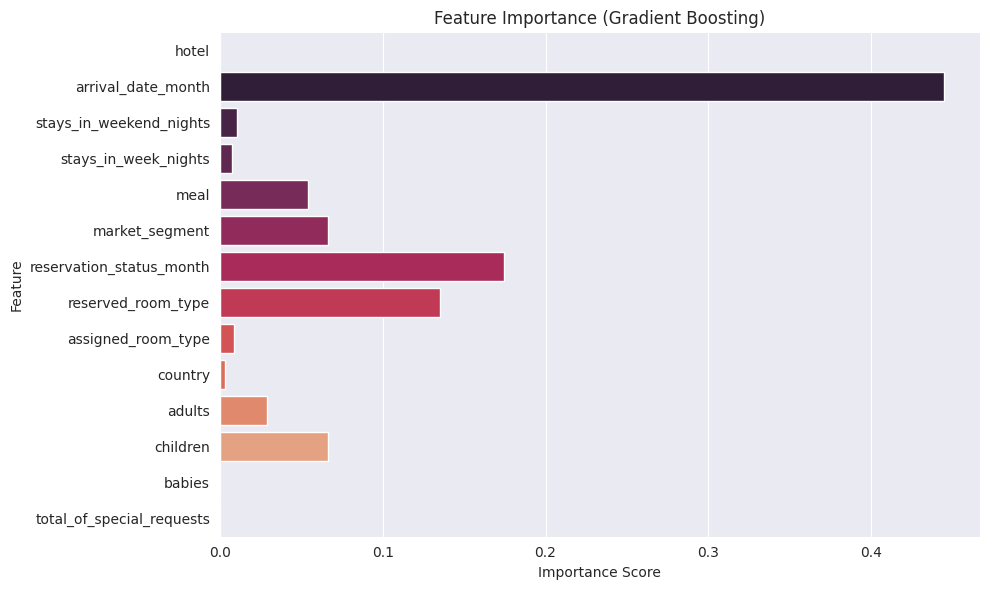

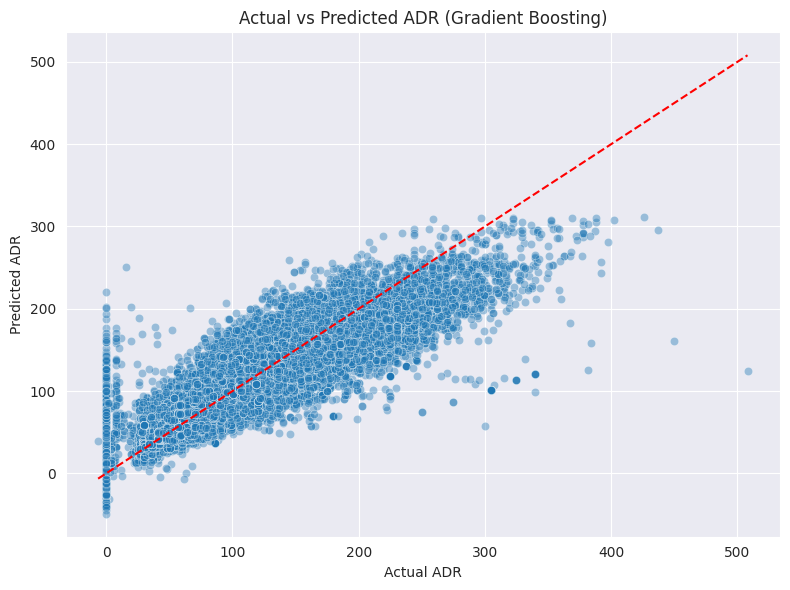

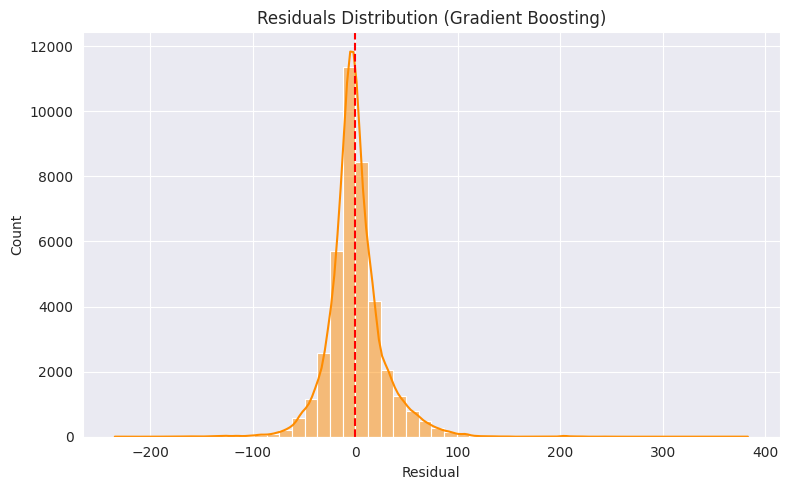

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Setup
gb_model = GradientBoostingRegressor(random_state=42, n_estimators=100, learning_rate=0.1)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_gb, rmse_scores_gb = [], []

# K-Fold CV
for train_idx, test_idx in kf.split(X_hotel):
    X_train, X_test = X_hotel.iloc[train_idx], X_hotel.iloc[test_idx]
    y_train, y_test = y_hotel.iloc[train_idx], y_hotel.iloc[test_idx]

    gb_model.fit(X_train, y_train)
    y_pred = gb_model.predict(X_test)

    r2_scores_gb.append(r2_score(y_test, y_pred))
    rmse_scores_gb.append(np.sqrt(mean_squared_error(y_test, y_pred)))

print("Gradient Boosting Regression:")
print("Mean R2:", np.mean(r2_scores_gb))
print("Mean RMSE:", np.mean(rmse_scores_gb))

# ===== Visualization =====

# Fit on all data
gb_model.fit(X_hotel, y_hotel)
y_pred_all = gb_model.predict(X_hotel)

# 1. Feature Importance
importances = gb_model.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=X_hotel.columns, palette='rocket')
plt.title("Feature Importance (Gradient Boosting)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 2. Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_hotel, y=y_pred_all, alpha=0.4)
plt.plot([y_hotel.min(), y_hotel.max()], [y_hotel.min(), y_hotel.max()], '--', color='red')
plt.title("Actual vs Predicted ADR (Gradient Boosting)")
plt.xlabel("Actual ADR")
plt.ylabel("Predicted ADR")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Residuals
residuals = y_hotel - y_pred_all
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=50, color='darkorange')
plt.title("Residuals Distribution (Gradient Boosting)")
plt.xlabel("Residual")
plt.axvline(0, linestyle='--', color='red')
plt.tight_layout()
plt.show()


XGBoost

XGBoost Regression:
Mean R2: 0.8501349115775229
Mean RMSE: 23.80124632404368


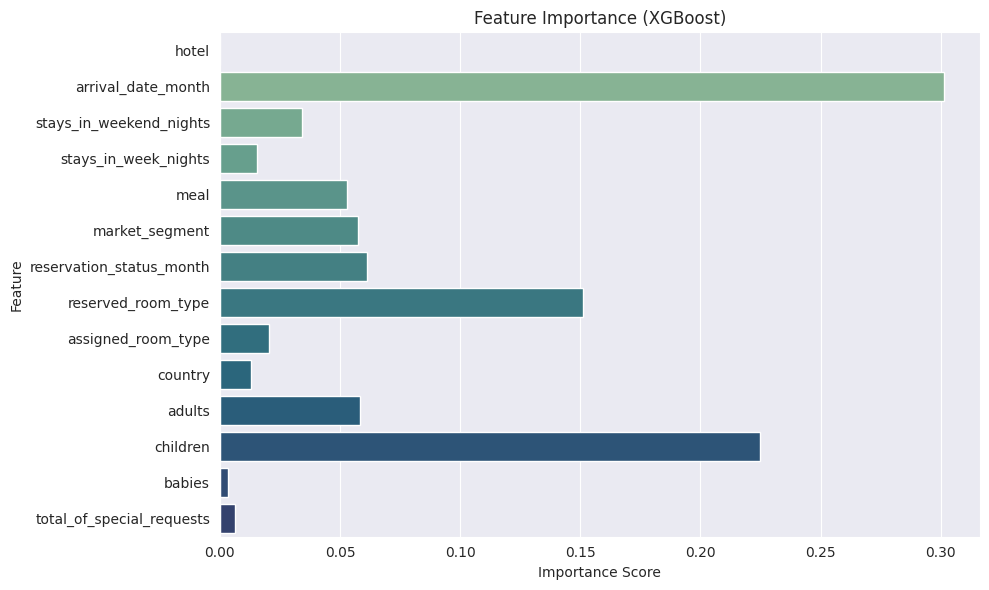

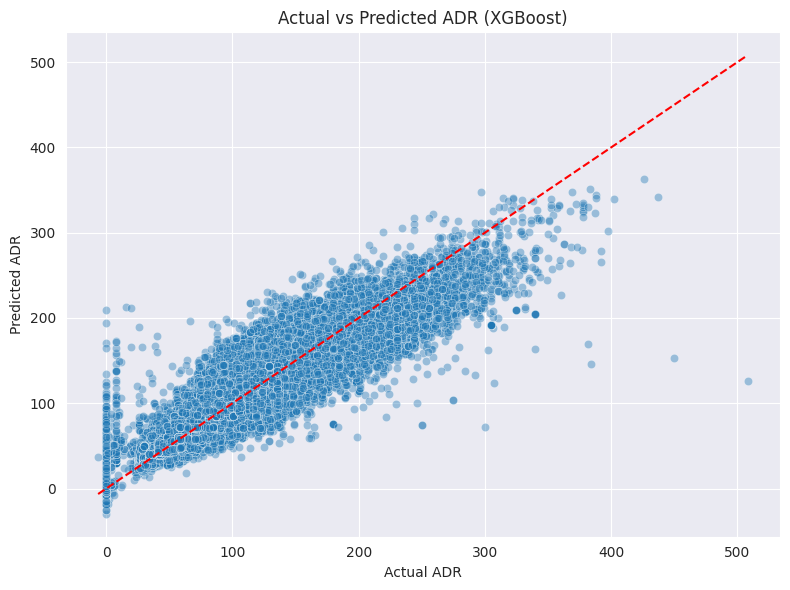

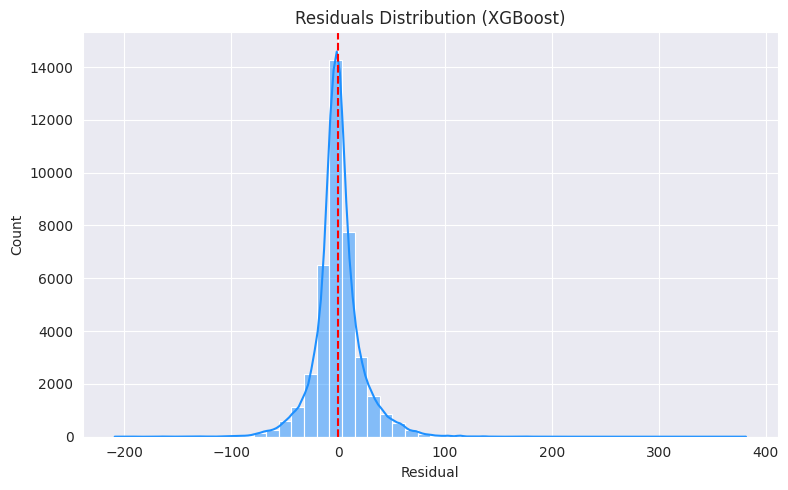

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initialize model
xgb_model = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1)

# Cross-validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_xgb, rmse_scores_xgb = [], []

# 5-Fold CV
for train_idx, test_idx in kf.split(X_hotel):
    X_train, X_test = X_hotel.iloc[train_idx], X_hotel.iloc[test_idx]
    y_train, y_test = y_hotel.iloc[train_idx], y_hotel.iloc[test_idx]

    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)

    r2_scores_xgb.append(r2_score(y_test, y_pred))
    rmse_scores_xgb.append(np.sqrt(mean_squared_error(y_test, y_pred)))

print("XGBoost Regression:")
print("Mean R2:", np.mean(r2_scores_xgb))
print("Mean RMSE:", np.mean(rmse_scores_xgb))

# Fit on entire dataset for visualization
xgb_model.fit(X_hotel, y_hotel)
y_pred_all = xgb_model.predict(X_hotel)

# 1. Feature Importance
importances = xgb_model.feature_importances_
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=X_hotel.columns, palette='crest')
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# 2. Actual vs Predicted ADR
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_hotel, y=y_pred_all, alpha=0.4)
plt.plot([y_hotel.min(), y_hotel.max()], [y_hotel.min(), y_hotel.max()], '--', color='red')
plt.title("Actual vs Predicted ADR (XGBoost)")
plt.xlabel("Actual ADR")
plt.ylabel("Predicted ADR")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Residuals Distribution
residuals = y_hotel - y_pred_all
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=50, color='dodgerblue')
plt.title("Residuals Distribution (XGBoost)")
plt.xlabel("Residual")
plt.axvline(0, linestyle='--', color='red')
plt.tight_layout()
plt.show()



In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# Collect final predictions
# NOTE: Ensure these are the predictions on the same test set
lr_pred = lr_pipeline.predict(X_test)
gb_pred = gb_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Dictionary of predictions
models = {
    "Linear Regression": lr_pred,
    "Gradient Boosting": gb_pred,
    "XGBoost": xgb_pred
}

# Calculate and collect metrics
regression_results = []

for name, y_pred in models.items():
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    regression_results.append({
        "Model": name,
        "R² Score": r2,
        "RMSE": rmse
    })

# Create and display the comparison DataFrame
regression_comparison_df = pd.DataFrame(regression_results)
print(regression_comparison_df)


               Model  R² Score       RMSE
0  Linear Regression  0.351538  49.632610
1  Gradient Boosting  0.800548  27.526050
2            XGBoost  0.864578  22.681351


Hypothesis Testing

In [ ]:
import scipy.stats as stats
import pandas as pd

# -----------------------------
# Hypothesis 1: Hotel-wise Cancellation Behavior
# H₀: Cancellation rates are equal for City and Resort Hotels
# H₁: Cancellation rates differ significantly
# -----------------------------
city_cancellations = full_table[full_table['hotel'] == 'City Hotel']['is_canceled']
resort_cancellations = full_table[full_table['hotel'] == 'Resort Hotel']['is_canceled']
hotel_stat, hotel_p = stats.ttest_ind(city_cancellations, resort_cancellations, equal_var=False)

# -----------------------------
# Hypothesis 2: Lead Time Impact on Cancellation
# H₀: Lead time does not affect cancellation likelihood
# H₁: Longer lead times are associated with higher cancellation
# -----------------------------
lead_canceled = full_table[full_table['is_canceled'] == 1]['lead_time']
lead_not_canceled = full_table[full_table['is_canceled'] == 0]['lead_time']
leadtime_stat, leadtime_p = stats.ttest_ind(lead_canceled, lead_not_canceled, equal_var=False)

# -----------------------------
# Hypothesis 3: Seasonality in ADR (Arrival Month)
# H₀: ADR does not vary across months
# H₁: ADR shows significant variation across months
# -----------------------------
adr_by_month = [group['adr'].values for _, group in full_table.groupby('arrival_date_month')]
anova_stat, anova_p = stats.f_oneway(*adr_by_month)

# -----------------------------
# Summary Table
# -----------------------------
hypothesis_results = pd.DataFrame({
    'Hypothesis': [
        'Hotel-wise Cancellation Behavior',
        'Lead Time Impact on Cancellation',
        'Seasonality in ADR (Arrival Month)'
    ],
    'Statistical Test': [
        'Independent t-test',
        'Independent t-test',
        'One-way ANOVA'
    ],
    'Test Statistic': [round(hotel_stat, 4), round(leadtime_stat, 4), round(anova_stat, 4)],
    'p-value': [f"{hotel_p:.5e}", f"{leadtime_p:.5e}", f"{anova_p:.5e}"],
    'Conclusion (α = 0.05)': [
        'Reject H₀ (Significant difference)' if hotel_p < 0.05 else 'Fail to reject H₀',
        'Reject H₀ (Significant difference)' if leadtime_p < 0.05 else 'Fail to reject H₀',
        'Reject H₀ (Significant difference)' if anova_p < 0.05 else 'Fail to reject H₀'
    ]
})

# Display the result
print(hypothesis_results)


                           Hypothesis    Statistical Test  Test Statistic  \
0    Hotel-wise Cancellation Behavior  Independent t-test         48.0913   
1    Lead Time Impact on Cancellation  Independent t-test         98.5228   
2  Seasonality in ADR (Arrival Month)       One-way ANOVA       2886.4310   

       p-value               Conclusion (α = 0.05)  
0  0.00000e+00  Reject H₀ (Significant difference)  
1  0.00000e+00  Reject H₀ (Significant difference)  
2  0.00000e+00  Reject H₀ (Significant difference)  
